# Task 1

In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [19]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #конвертируем в оттенки серого
image = image_gray

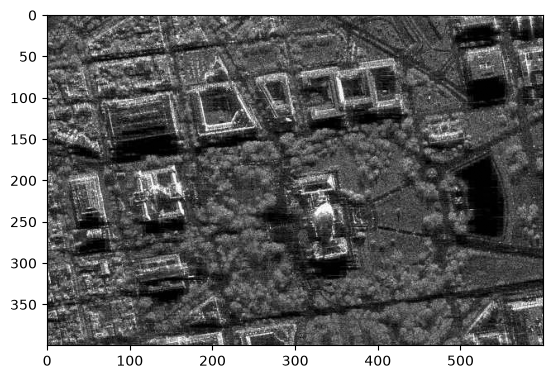

In [20]:
plt.imshow(image, cmap='gray')

# Task 2

Количество бит, выделенное на один канал, определяет, сколько уникальных оттенков этого цвета может отобразить монитор или записать камера

Гистограмма — это визуальный график распределения пикселей по их яркости.

In [21]:
#посмотреть сколько бит на канал uint8 - 8 бит
data_type = image.dtype
print(f"Тип данных: {data_type}")

Тип данных: uint8


In [22]:
histSize = 256 # 2^8 = 256 из прошлого просмотра
histRange = (0, 256)
accumulate = False
#вычисление гистограммы синего канала изображения
b_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

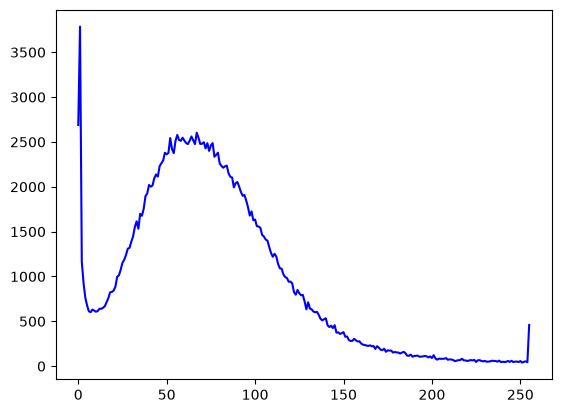

In [23]:
plt.plot(b_hist, color='b')

# Task 3

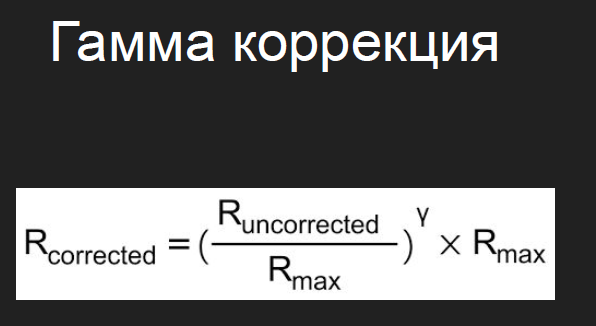

In [24]:
R_max = 255.0 # 2 ^ 8 uint8 - 1 (от 0 до 255)
def gamma_correction(image, gamma):
    """
    Применяет гамма-коррекцию к изображению с помощью двух циклов for.
    Поддерживает как цветные (BGR), так и серые (Grayscale) изображения.
    """
    if gamma == 1.0:
        return image.copy()

    # Копируем изображение, чтобы не менять оригинал
    result = image.copy()
    
    # Получаем высоту и ширину (и количество каналов, если они есть)
    shape = image.shape
    height, width = shape[0], shape[1]

    # Перебираем пиксели по высоте и ширине
    for y in range(height):
        for x in range(width):
                old_value = image[y, x]
                new_value = int(((old_value / R_max) ** gamma) * R_max) 
                result[y, x] = np.clip(new_value, 0, R_max) # ограничение превышения R_max
                
    return result


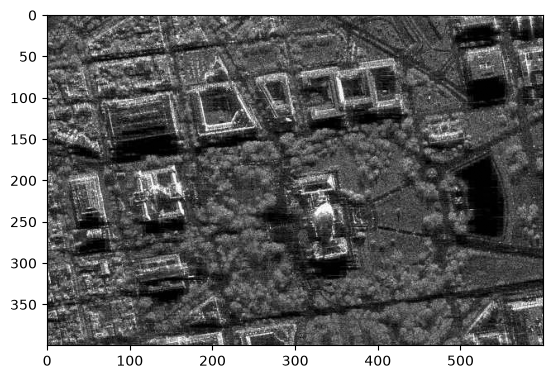

In [25]:
image_not_correction = gamma_correction(image, 1.0)
plt.imshow(image_not_correction, cmap='gray')

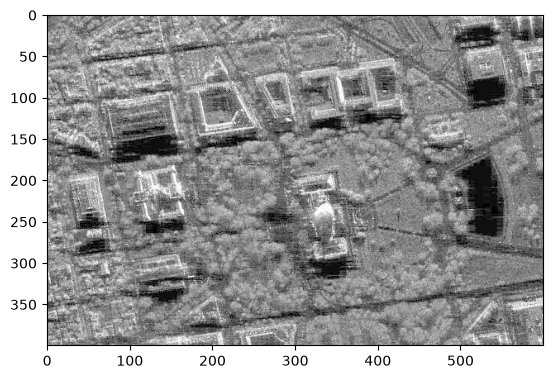

In [26]:
image_gamma_less_1 = gamma_correction(image, 0.5)
plt.imshow(image_gamma_less_1, cmap='gray')

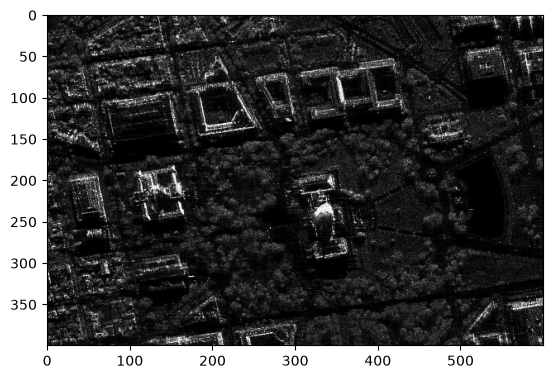

In [27]:
image_gamma_more_1 = gamma_correction(image, 2)
plt.imshow(image_gamma_more_1, cmap='gray')

# Task 4

In [28]:
from skimage.metrics import structural_similarity, mean_squared_error
def photo_comparison(image_src, image):
    (ssim, diff) = structural_similarity(image_src, image, full=True)
    diff = (diff * 255).astype("uint8")
    mse = mean_squared_error(image_src, image)
    print(f"SSIM: {ssim} MSE: {mse}")

In [29]:
photo_comparison(image_gray, image_gray)

SSIM: 1.0 MSE: 0.0


In [30]:
photo_comparison(image_gray, image_gamma_less_1)

SSIM: 0.7875008686792753 MSE: 3250.429145833333


In [31]:
photo_comparison(image_gray, image_gamma_more_1)

SSIM: 0.5270459922820344 MSE: 2383.7636375


# Task 5

In [32]:
eq_gray = cv2.equalizeHist(image_gray)

photo_comparison(image_gray, eq_gray)

SSIM: 0.6991361032506224 MSE: 4021.7966791666668


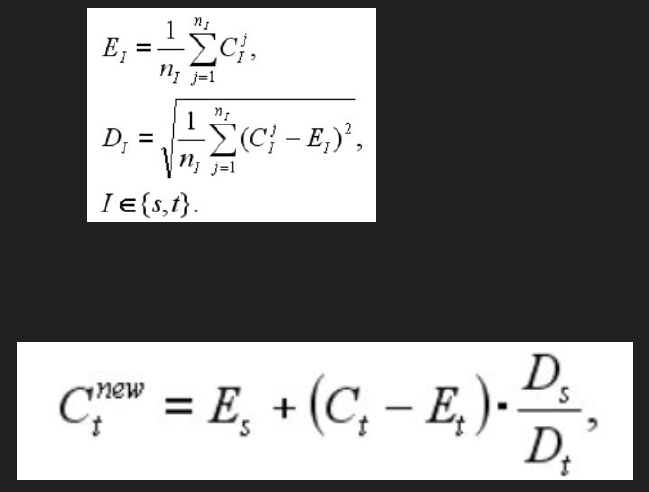

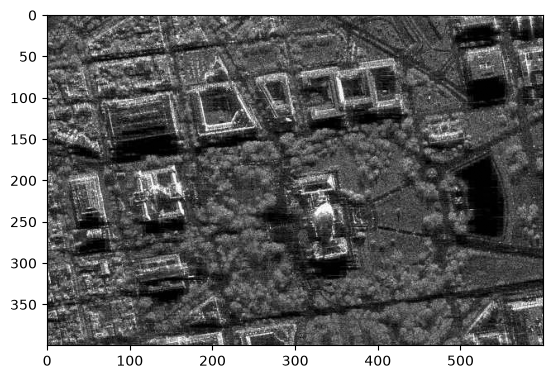

In [33]:
plt.imshow(image_gray, cmap='gray')

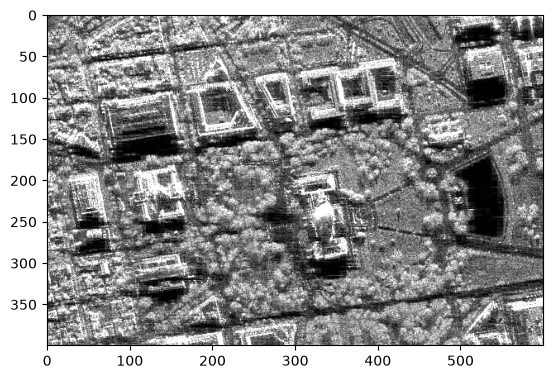

In [34]:
E_s = np.mean(eq_gray)
D_s = np.std(eq_gray)
C_t = image.astype(np.float32) # uint8 меняем на float32 для вычисления формул
D_t = np.std(C_t)
if D_t < 1e-6:
    result = C_t
else:
    result = E_s + (C_t - np.mean(C_t)) * (D_s / D_t)
result_image = np.clip(np.round(result), 0, 255).astype(np.uint8)
plt.imshow(result_image, cmap='gray')

# Task 6

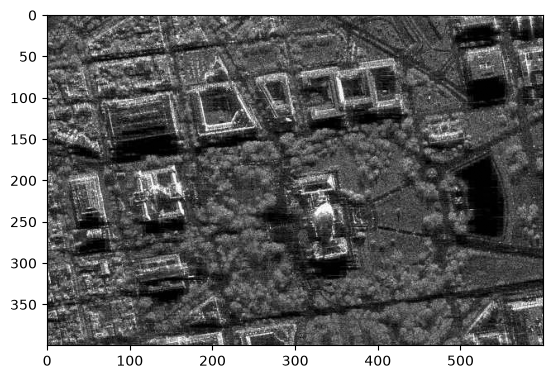

In [35]:
plt.imshow(image_gray, cmap='gray')

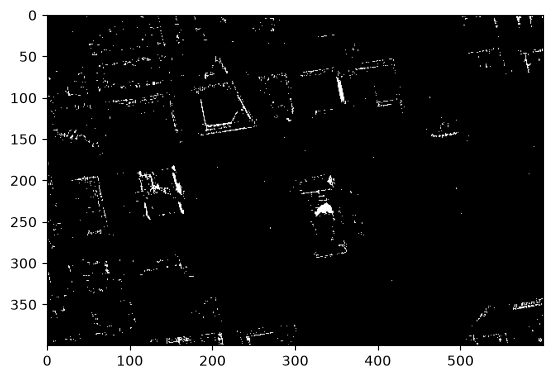

In [36]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)
plt.imshow(thresh1, cmap='gray')

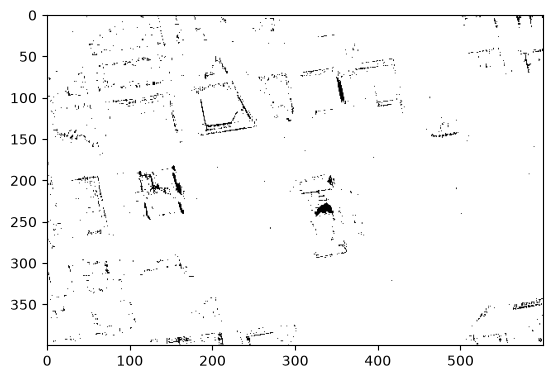

In [37]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY_INV)
plt.imshow(thresh1, cmap='gray')

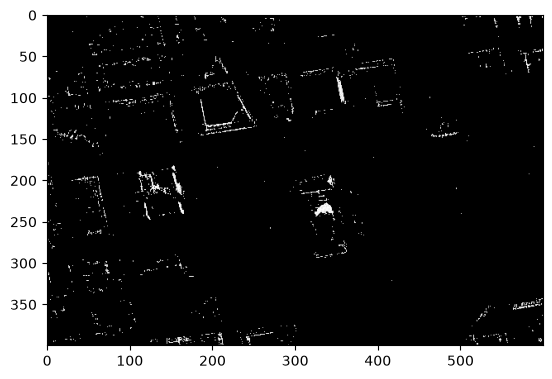

In [38]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_TOZERO)
plt.imshow(thresh1, cmap='gray')

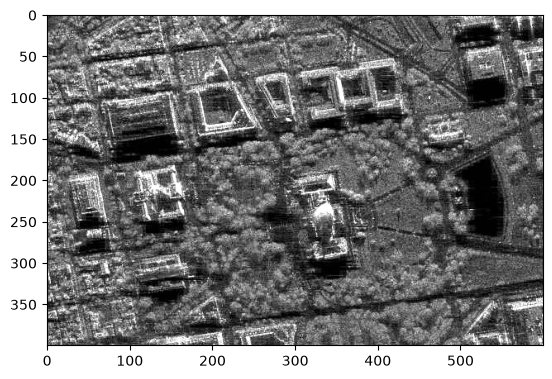

In [39]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_TRUNC)
plt.imshow(thresh1, cmap='gray')

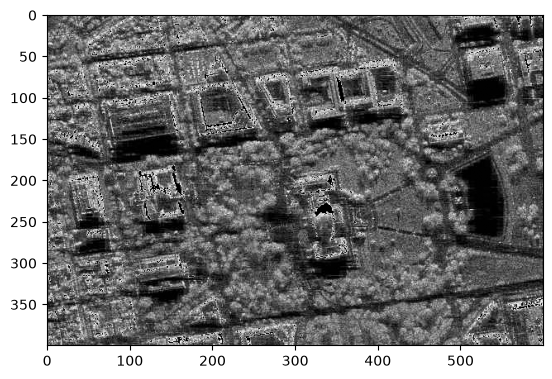

In [40]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_TOZERO_INV)
plt.imshow(thresh1, cmap='gray')